# ML from DFT data

In [1]:
import pickle
import os
import glob
import numpy as np
import pdb
import pandas as pd
from importlib.machinery import SourceFileLoader
import re
import sys
from tqdm.notebook import tqdm_notebook
from seaborn import heatmap
import seaborn as sns
from BopFoxFeaturizer.HelperFunctions import get_useful_features
from BopFoxFeaturizer.HelperFunctions import cleanfeaturenames
from BopFoxFeaturizer.HelperFunctions import histoff_realfeatures
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rc('figure', figsize=(15,10))
plt.rc('legend',fontsize=24)
plt.rc('axes',labelsize=28)
plt.rc('xtick',labelsize=24)
plt.rc('ytick',labelsize=24)
from BopFoxFeaturizer.FeatureConcatenate import stackdata
from BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
from BopFoxFeaturizer.Featurizer import Featurizer
from BopFoxFeaturizer import HelperFunctions as HF
#stackdata = SourceFileLoader('stackdata','BopFoxFeaturizer/FeatureConcatenate.py').load_module().stackdata
# Original DFT Data
%run SourceDevelopementVersion.py
# which loads Featu
import glob

# Parameters 

In [2]:
CASE = 'INITIAL'  #, 'INITIAL', RELAXED
MODEL = 'ORTHOGONALOS' #, 'ORTHOGONAL', 'CANONICAL','ORTOGONALOS'
CUT_OFF = 'TABLECUTOFF' # 'TABLECUTOFF', 'HISTCUTOFF'
E_MODE ='WUBIND'
C_RITERION = 'test_score'  # test_score, train_score, err
SEARCH_MODE = 'score_only' #score_only, index_too
TARGET = 'V0'
MOMENTS = 15

# Helpeer Functions 

In [3]:
from Tools import CaseNamer, Plotting

In [4]:
FileNames = CaseNamer(
    CASE, MODEL,
    CUTOFF=CUT_OFF, EMODE=E_MODE, CRITERION=C_RITERION, SEARCHMODE=SEARCH_MODE, TARGET=TARGET
)

# Load Features

## Load briefsummary and its features

In [5]:
BS = StructSummaryParser().BriefSummary
Features = Featurizer(BS)

## Load the BOP for the selected case

In [6]:
BOPCOEF_FILE = f'CNAveragedCRCOW_{CASE}_NSC_{MODEL}_{CUT_OFF}_{E_MODE}_{MOMENTS}.pkl'
BopfoxFeatures = pd.read_pickle(BOPCOEF_FILE)
#BopfoxFeatures.drop(columns=['NSC_U_bond_atom_list'], inplace=True)
#BopfoxFeatures.drop(columns=['NSC_U_bind'], inplace=True)

In [7]:
BopfoxFeatures

,all_NSC_U_bind_0,all_NSC_U_bond_atom_0,all_NSC_U_bond_atom_list_0,CN12_NSC_U_bond_atom_list_0,CN13_NSC_U_bond_atom_list_0,CN14_NSC_U_bond_atom_list_0,CN15_NSC_U_bond_atom_list_0,CN16_NSC_U_bond_atom_list_0,all_NSC_moments_0,all_NSC_moments_1,...,CN13_NSC_Ainf_0,CN14_NSC_Ainf_0,CN15_NSC_Ainf_0,CN16_NSC_Ainf_0,all_NSC_Binf_0,CN12_NSC_Binf_0,CN13_NSC_Binf_0,CN14_NSC_Binf_0,CN15_NSC_Binf_0,CN16_NSC_Binf_0
Co_pv10W_sv14.C36-ABBAB.FM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0.0,0.000000,0.0,-6.578786,5.830383,5.872895,0.0,0.00000,0.0,5.745359
Co_pv10W_sv14.C36-ABBAB.NM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0.0,0.000000,0.0,-6.578786,5.830383,5.872895,0.0,0.00000,0.0,5.745359
Co_pv10W_sv14.C36-ABBBA.FM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0.0,0.000000,0.0,-6.578786,5.830383,5.872895,0.0,0.00000,0.0,5.745359
Co_pv10W_sv14.C36-ABBBA.NM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0.0,0.000000,0.0,-6.578786,5.830383,5.872895,0.0,0.00000,0.0,5.745359
Co_pv10W_sv14.C36-BABAB.FM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0.0,0.000000,0.0,-6.578786,5.830383,5.872895,0.0,0.00000,0.0,5.745359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
W_sv1.bcc.FM,-21.021407,-21.021407,-21.021407,0.000000,0.0,0.000000,0.0,0.000000,-5.56,53.437900,...,0.0,0.000000,0.0,0.000000,6.222663,0.000000,0.0,0.00000,0.0,0.000000
W_sv2.hcp.FM,-40.187813,-40.187813,-30.140859,0.000000,0.0,0.000000,0.0,0.000000,-5.56,52.935100,...,0.0,0.000000,0.0,0.000000,5.187294,0.000000,0.0,0.00000,0.0,0.000000
W_sv4.fcc-cubic.FM,-81.028519,-81.028519,-35.449977,0.000000,0.0,0.000000,0.0,0.000000,-5.56,52.935100,...,0.0,0.000000,0.0,0.000000,5.763108,0.000000,0.0,0.00000,0.0,0.000000
W_sv53.R.NM,-1077.572644,-1078.835373,-40.344047,0.000000,0.0,0.000000,0.0,0.000000,-5.56,54.196170,...,0.0,0.000000,0.0,0.000000,5.435779,0.000000,0.0,0.00000,0.0,0.000000


In [75]:
composition_features = pd.read_pickle('initial/matminer_composition_features.pkl')

In [77]:
atomic_features = pd.read_pickle('initial/matminer_atomic_features.pkl')

In [81]:
atomic_features.columns = atomic_features.columns.str.replace('MagpieData ','')

## clean features: reduntandly convert all features to float and mean across sites

In [8]:
BopfoxFeatures.dropna(how='any',inplace=True)
Mag = Features.MagFeature[BopfoxFeatures.index]
BopfoxFeatures['MagConfig'] = Mag

## concentration feature

In [9]:
X = Features.get_fractions_by_components()

In [10]:
categorical_compo = pd.get_dummies(BS[['atom_A','atom_B','atom_C']])

In [11]:
BOP = pd.concat([BopfoxFeatures, X, categorical_compo], axis=1)

In [12]:
BOP

,all_NSC_U_bind_0,all_NSC_U_bond_atom_0,all_NSC_U_bond_atom_list_0,CN12_NSC_U_bond_atom_list_0,CN13_NSC_U_bond_atom_list_0,CN14_NSC_U_bond_atom_list_0,CN15_NSC_U_bond_atom_list_0,CN16_NSC_U_bond_atom_list_0,all_NSC_moments_0,all_NSC_moments_1,...,Cr_pv,W_sv,atom_A_Co_pv,atom_A_Cr_pv,atom_A_W_sv,atom_B_,atom_B_Co_pv,atom_B_W_sv,atom_C_,atom_C_W_sv
Co_pv10W_sv14.C36-ABBAB.FM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0.0,0.583333,1,0,0,0,0,1,1,0
Co_pv10W_sv14.C36-ABBAB.NM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0.0,0.583333,1,0,0,0,0,1,1,0
Co_pv10W_sv14.C36-ABBBA.FM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0.0,0.583333,1,0,0,0,0,1,1,0
Co_pv10W_sv14.C36-ABBBA.NM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0.0,0.583333,1,0,0,0,0,1,1,0
Co_pv10W_sv14.C36-BABAB.FM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0.0,0.583333,1,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
W_sv1.bcc.FM,-21.021407,-21.021407,-21.021407,0.000000,0.0,0.000000,0.0,0.000000,-5.56,53.437900,...,0.0,1.000000,0,0,1,1,0,0,1,0
W_sv2.hcp.FM,-40.187813,-40.187813,-30.140859,0.000000,0.0,0.000000,0.0,0.000000,-5.56,52.935100,...,0.0,1.000000,0,0,1,1,0,0,1,0
W_sv4.fcc-cubic.FM,-81.028519,-81.028519,-35.449977,0.000000,0.0,0.000000,0.0,0.000000,-5.56,52.935100,...,0.0,1.000000,0,0,1,1,0,0,1,0
W_sv53.R.NM,-1077.572644,-1078.835373,-40.344047,0.000000,0.0,0.000000,0.0,0.000000,-5.56,54.196170,...,0.0,1.000000,0,0,1,1,0,0,1,0


## define the column names by type of feature

In [13]:
allcolumns = BOP.columns

In [14]:
columns_Mag =BOP.columns[BOP.columns.str.contains('MagConfig')]
columns_U =BOP.columns[BOP.columns.str.contains('U_bind')]
columns_bn = BOP.columns[BOP.columns.str.contains('bn')]
columns_sigma =BOP.columns[BOP.columns.str.contains('SIGMA')] 
columns_moments = BOP.columns[BOP.columns.str.contains('moment')]
columns_an = BOP.columns[BOP.columns.str.contains('an')]
columns_cn12 = BOP.columns[BOP.columns.str.contains('CN12')] 
columns_cn14 = BOP.columns[BOP.columns.str.contains('CN14')] 
columns_cn15 = BOP.columns[BOP.columns.str.contains('CN15')] 
columns_cn16 = BOP.columns[BOP.columns.str.contains('CN16')] 
columns_all = BOP.columns[BOP.columns.str.contains('all')] 

In [15]:
feature_titles = pd.Series(
    HF.cleanfeaturenames([ s.replace('NSC_','').replace('MagConfig_0','MagConfig').replace('bind_0','bind') for s in allcolumns ]), index=allcolumns
)

In [16]:
real_feature = HF.get_useful_features(BOP, allcolumns)

In [17]:
len(real_feature)

306

In [18]:
def colsgroup(kind):
    return [ f for f in real_feature if kind in f] 

In [19]:
useful = {f: colsgroup(f) for f in ['an','bn','moment','SIGMA', 'U_bind','MagConfig']}

# Targets

$ \Delta E_F  = \dfrac{1}{N_{atoms}} \left( E_{Total} - \sum _{i} N_i E_i \right) $

In [20]:
groundstates=Features.get_ground_states_energies()
BS['EF'] = Features.get_formation_energy(ground_states_dic=groundstates)
BS = BS.dropna()
DATA = BOP.copy()
DATA[['B0','V0','EF','E0']]=BS[['B0','V0','EF','E0']]

## Distribution of targets

### $E_{F}$

In [21]:
Out_In_First = DATA[~((DATA['EF']>-1) & (DATA['EF']<2))]

In [22]:
DATA = DATA[(DATA['EF'] > -1) & (DATA['EF']< 2)]

### $E_0$

In [23]:
DATA = DATA[(DATA['E0']>-100) & (DATA['E0']<10)]

In [24]:
DATA.shape

(1684, 408)

## B0

In [25]:
DATA = DATA[(DATA['B0'])>0 & (DATA['B0']<500)]

## V0

In [26]:
DATA = DATA[DATA['V0']<50]

In [27]:
DATA.shape

(1681, 408)

## Drop Nans !

In [28]:
DATA.dropna(how='any', axis=0,inplace=True)

In [29]:
DATA.shape

(1681, 408)

# Classification and weighting

Text(0, 0.5, '')

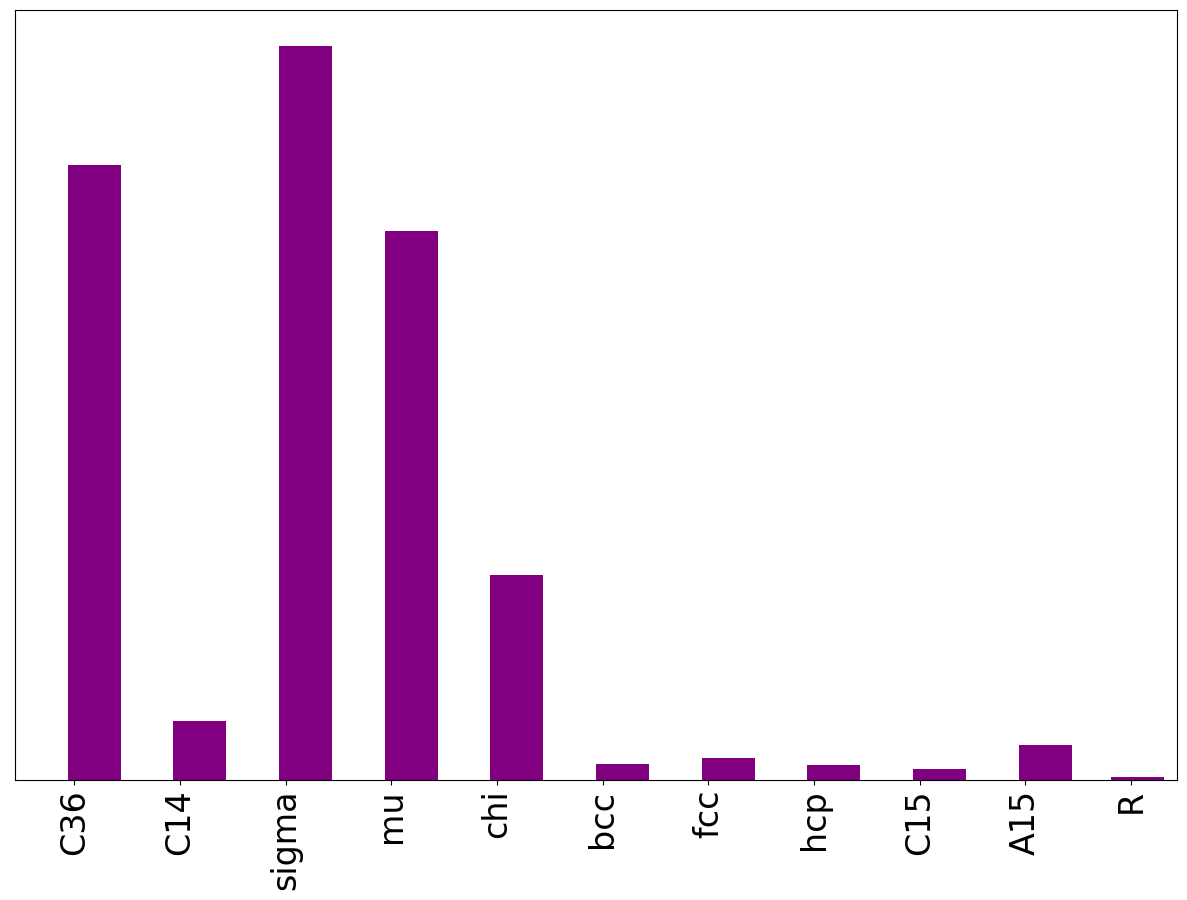

In [30]:
from BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    DATA.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=DATA.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

plt.hist(Target_Class, bins=80, density = True, width=0.5, align='left', color = 'purple')
plt.xticks(rotation=90); yticks = plt.yticks([])
plt.ylabel('')

## Class Weights

In [31]:
Classes = pd.DataFrame(Target_Class.values, columns=['Class'], index=DATA.index)
Target_Class_Count = Target_Class.value_counts()
Classes['Weights'] = 1/(Target_Class_Count[Target_Class]/Target_Class_Count.sum()).values #Target_Class_Count.sum()

In [32]:
data_w_classes =pd.concat([DATA,Classes['Class'].loc[DATA.index]], axis=1) 

## Remove C14!

DATA = DATA[data_w_classes['Class']!='C14']
Classes = Classes[Classes['Class']!='C14']

# Finally some Machine Learning

[![scikit-logo](https://scikit-learn.org/stable/_static/scikit-learn-logo-small.png#background-color:"#FFFFFF")](https://scikit-learn.org/stable/) is a standard tool for machine learning in python. The documentation in their webpage is often a good refference for tutorials, methods and Theory of Machine Learning. 

In [33]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Lasso

## Feature Selection 

In [34]:
from sklearn.feature_selection import  (
    RFECV, 
    SelectKBest, 
    SequentialFeatureSelector,
    mutual_info_regression
)

In [35]:
from sklearn.model_selection import GridSearchCV

## Helper Functions

In [36]:
def plot_the_errors(THISERRORS,thecase):
    alltheclases = np.unique(Classes['Class'])
    thebadclasses = ['hcp', 'bcc', 'fcc','others','delta','R','C15']
    thegoodclases = [c for c in alltheclases if c not in thebadclasses ]
    fig, ax = plt.subplots(len(thegoodclases),1, sharex=True, figsize =(10,2*len(thegoodclases)))
    for i, classes in enumerate(thegoodclases) :
        thiserrors = np.abs(THISERRORS[Classes['Class']==classes])
        e = ax[i].hist (thiserrors, density=False, bins=100, label=classes)
        ax[i].annotate(classes, (0.8,0.5),xycoords = 'axes fraction', fontsize=20)
#    ax[-1].set_xlim([-0.01,1.0])
    ax[-1].set_ylabel('Density Counts',y=4), plt.xlabel('$|  Target^{predicted} -  Target^{True} | $')
    fig.tight_layout()
    fig.savefig(FileNames.get_plot_filename('Errors_by_class', thecase))
#    fig.savefig('graphs/Errors_by_class_{}_{}_{}_{}.pdf'.format(case, CASE, MODEL, CUTOFF))
    

def plot_the_prediction_line(theprediction, thepredictionovertest, thecase):
    fig, ax = plt.subplots()
    ax.plot(theprediction, DATA[TARGET],'o', label='full dataset')
    ax.plot(thepredictionovertest, Y_test,'o', label='test set')
    ax.plot(DATA[TARGET], DATA[TARGET],'-k')
    ax.legend()
    ax.set_xlabel('True')# $\Delta E_F$')
    ax.set_ylabel('predicted')# $\Delta E_F$')
    fig.savefig(FileNames.get_plot_filename('Predictionline',thecase))
#    fig.savefig('graphs/predictionline_{}_{}.pdf'.format(themodel,CASE, MODEL, CUTOFF))

def train_test_errors(themodel, Xtrain, Xtest, Ytrain, Ytest):
    Ypredict_train = themodel.predict(Xtrain)
    Ypredict_test = themodel.predict(Xtest)
    return {'train': mean_squared_error(Ytrain, Ypredict_train ,squared=False), 'test':  mean_squared_error(Ytest, Ypredict_test,squared=False )}

def make_simple_pipe(model, with_scaler = True):
        if with_scaler:
            return Pipeline([('scaler',MinMaxScaler()),('regressor', model())])
        else:
            return Pipeline([('regressor', model())])

# Train test split 

In [37]:
X_train, X_test, w_train, w_test,  Y_train, Y_test = train_test_split(DATA[real_feature],Classes['Weights'], DATA[TARGET],test_size=0.2, shuffle=True)

I need Lists of errors to compare methods

In [38]:
mses = {}

I also need to remove targets from feature names

## simple regressor - random forest

In [39]:
simple_model = make_simple_pipe(RandomForestRegressor)

In [40]:
simple_model.fit(X_train,Y_train)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('regressor', RandomForestRegressor())])

In [41]:
mses['random forest regressor'] = train_test_errors(simple_model, X_train, X_test,Y_train, Y_test)

In [42]:
mses

{'random forest regressor': {'train': 0.1356233270102038,
  'test': 0.1840438387501926}}

In [44]:
simple_model_noscaler = make_simple_pipe(RandomForestRegressor, with_scaler=False)

In [45]:
simple_model_noscaler.fit(X_train, Y_train)

Pipeline(steps=[('regressor', RandomForestRegressor())])

In [46]:
mses['random forest regressor noscale'] = train_test_errors(simple_model_noscaler, X_train, X_test, Y_train, Y_test)

In [47]:
mses

{'random forest regressor': {'train': 0.1356233270102038,
  'test': 0.1840438387501926},
 'random forest regressor noscale': {'train': 0.13844650916512746,
  'test': 0.1849889889105817}}

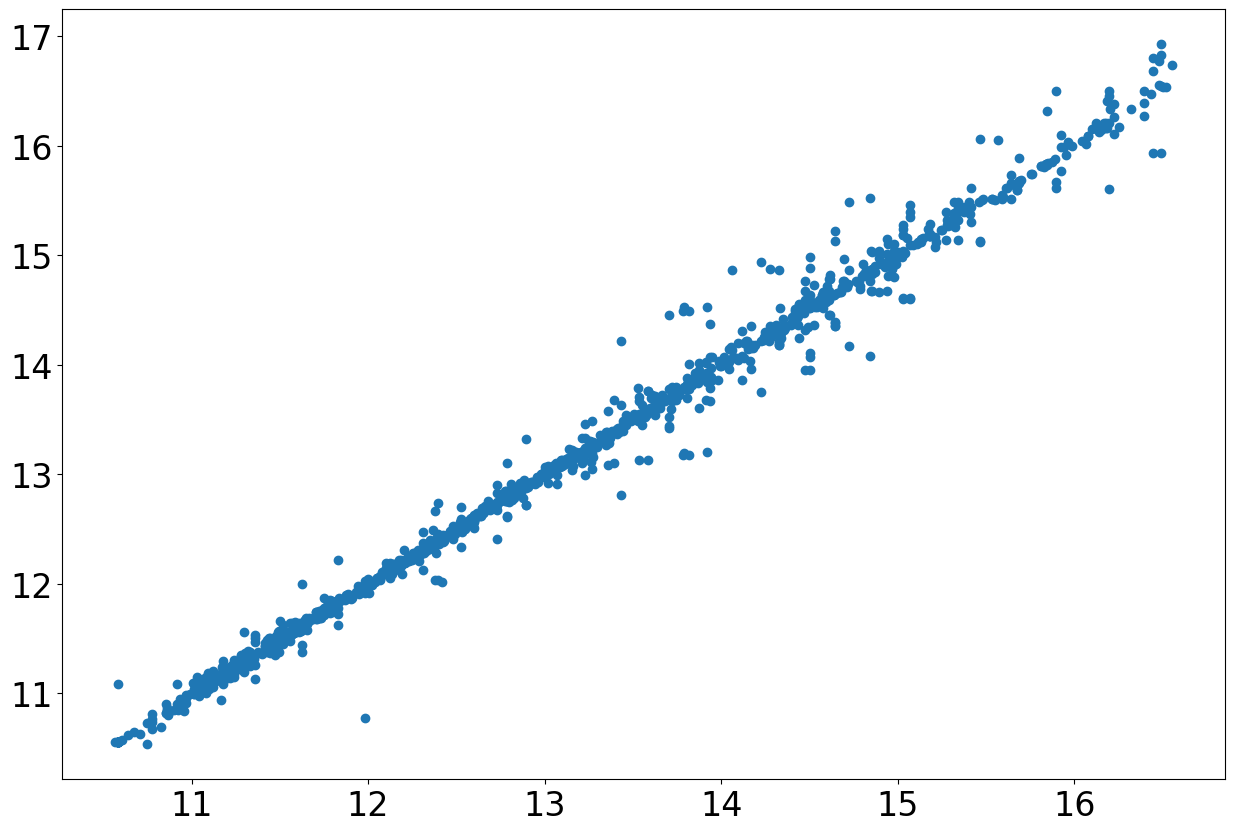

In [48]:
plt.plot(simple_model.predict(X_train),Y_train,'o')
#plt.plot(simple_model_noscaler.predict(X_train),Y_train,'o')

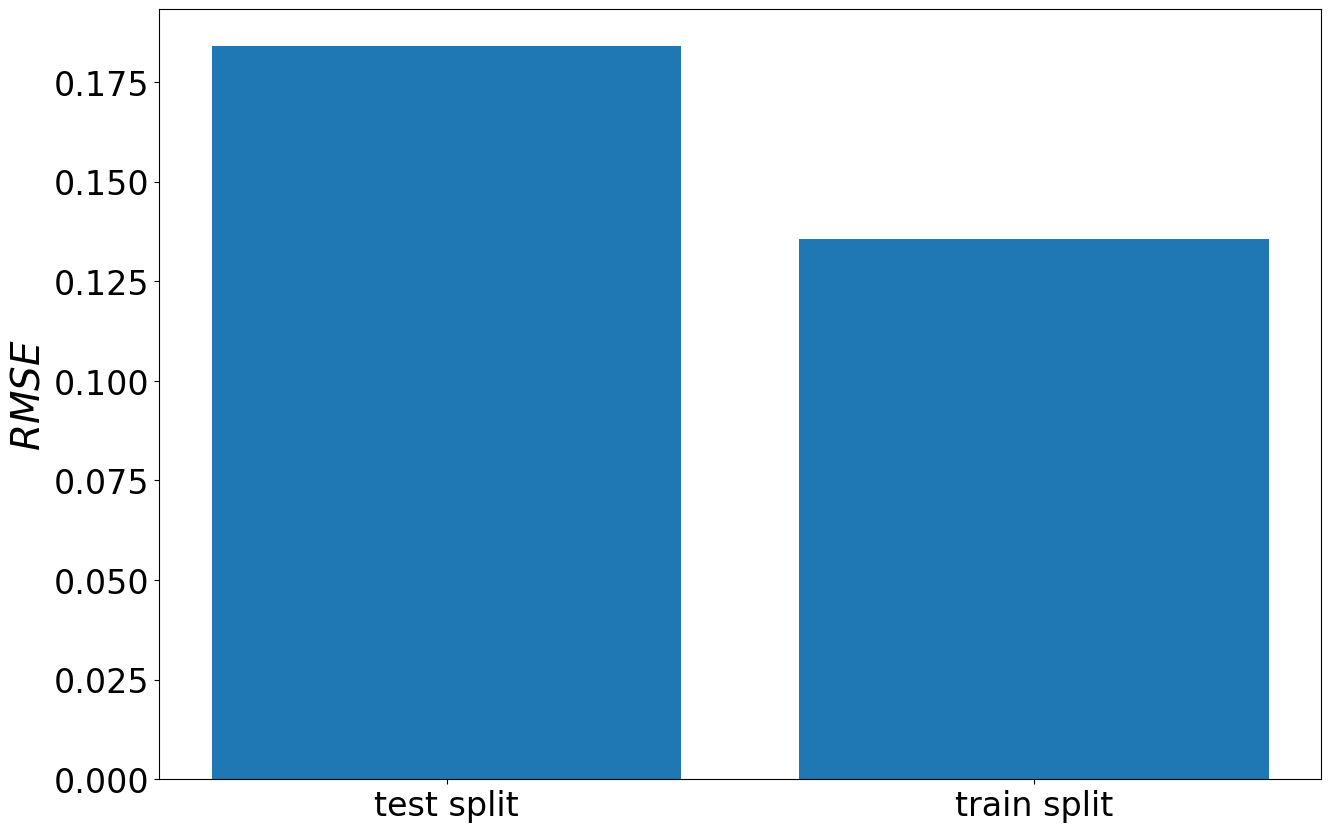

In [49]:
plt.bar(['test split','train split'],[mses['random forest regressor']['test'], mses['random forest regressor']['train']])
label = plt.ylabel('$RMSE$')

In [50]:
YPREDICT = simple_model.predict(DATA[real_feature])
Y_predict_test = simple_model.predict(X_test)
ERRORS = (YPREDICT - DATA[TARGET]).map(np.abs)

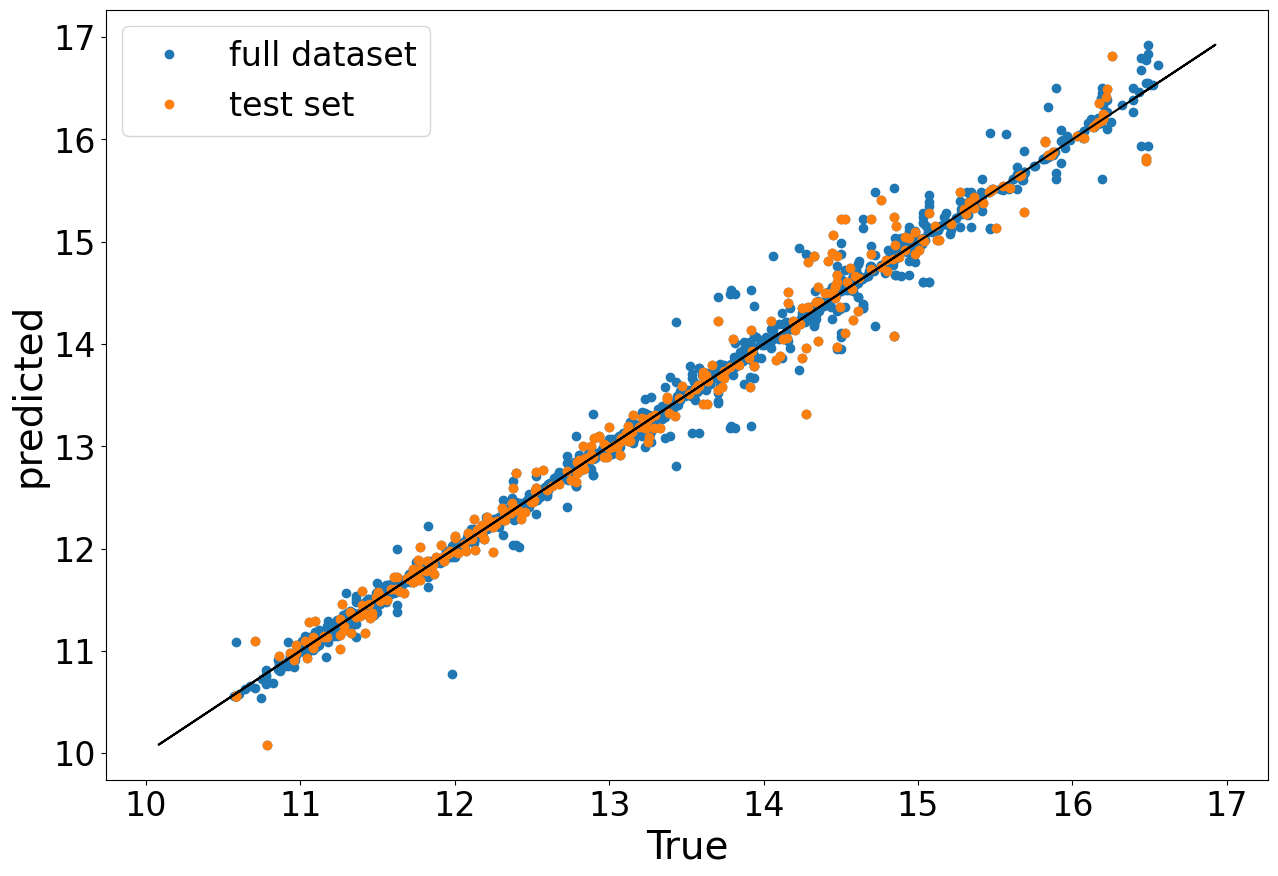

In [51]:
plot_the_prediction_line(YPREDICT, Y_predict_test, 'RandomForestRegressor')

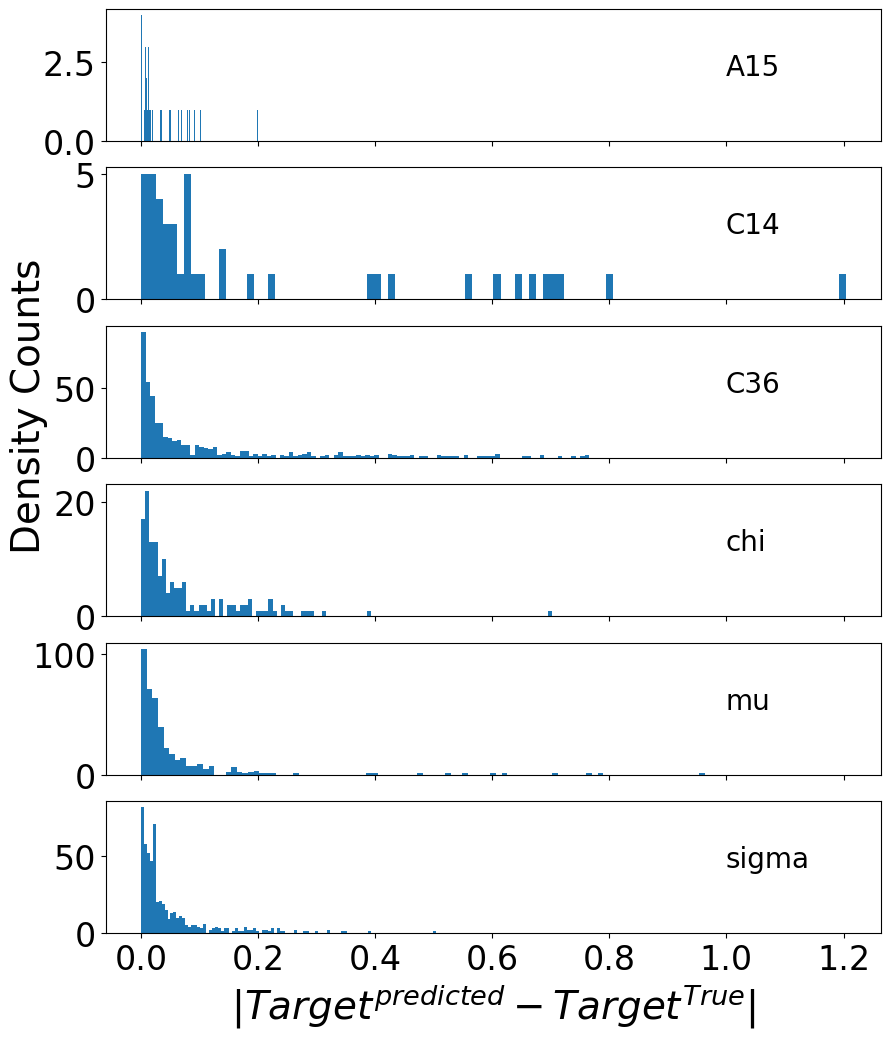

In [52]:
plot_the_errors(ERRORS,'RandomForestRegressor')

In [54]:
ERRORS[ERRORS > 1]

Cr_pv4Co_pv2W_sv6.C14-BCA.FM    1.2035
Name: V0, dtype: float64

Now I will use this vlolume to try to target the formation energy

In [63]:
DATA['VP'] = simple_model.predict(DATA[real_feature])

In [58]:
intermediate_feature = ['VP']

In [59]:
model_formation_energy = RandomForestRegressor()

In [64]:
X_train_ef, X_test_ef , Y_train_ef, Y_test_ef = train_test_split(DATA[real_feature+intermediate_feature], DATA['EF'])

In [67]:
model_formation_energy.fit(X_train_ef, Y_train_ef)

RandomForestRegressor()

In [72]:
mses['model_formation_energy'] = {
    'test': mean_squared_error(Y_test_ef, model_formation_energy.predict(X_test_ef), squared=False),
    'train': mean_squared_error(Y_train_ef, model_formation_energy.predict(X_train_ef), squared=False)
}

In [73]:
mses

{'random forest regressor': {'train': 0.1356233270102038,
  'test': 0.1840438387501926},
 'random forest regressor noscale': {'train': 0.13844650916512746,
  'test': 0.1849889889105817},
 'model_formation_energy': {'test': 0.07444864449608783,
  'train': 0.04991459904637317}}

There is a big variety of regression methods available in scikit-learn package.
[See the documentation](https://scikit-learn.org/stable/supervised_learning.html#supervised-learninghttps://scikit-learn.org/stable/supervised_learning.html#supervised-learning)

# Feature Selection

## Random Forest + selectkbest

In [ ]:
useful_feature = []
for key in useful.keys():
    useful_feature+=useful[key]

In [ ]:
Selector = SelectKBest(mutual_info_regression, k=10)
Selector.fit(X_train[useful_feature], Y_train)

In [ ]:
simple_model = RandomForestRegressor()

In [ ]:
np.array(useful_feature)[Selector.get_support()]

In [ ]:
simple_model.fit(X_train[np.array(useful_feature)[Selector.get_support()]], Y_train)

In [ ]:
Y_predict = simple_model.predict(X_train[np.array(useful_feature)[Selector.get_support()]])

mses['simplekbest'] = {'train': mean_squared_error(Y_train, Y_predict, squared=False)}

Y_test_predict = simple_model.predict(X_test[np.array(useful_feature)[Selector.get_support()]])

mses['simplekbest'].update({'test': mean_squared_error(Y_test, Y_test_predict,squared=False)})

In [ ]:
mses

### on a pipeline

In [ ]:
RF_SelectKbest = Pipeline(
    [
        ('feature_selection', SelectKBest()),
        ('regression', RandomForestRegressor())
    ]
)

In [ ]:
RF_SelectKbest.fit(X_train, Y_train)

In [ ]:
Y_predict_Pipe  = RF_SelectKbest.predict(X_train)

mses['RF_SK_Pipe'] = {'train': mean_squared_error(Y_train, Y_predict_Pipe, squared=False) }

Y_test_predict_Pipe = RF_SelectKbest.predict(X_test)

mses['RF_SK_Pipe'].update({'test': mean_squared_error(Y_test, Y_test_predict_Pipe, squared=False)})

In [ ]:
np.array(real_feature)[RF_SelectKbest[0].get_support()]

In [ ]:
mses

### with cross validation

In [ ]:
Params= {'feature_selection__k':np.arange(10,30), 'regression__max_depth':[20]} #,1, 2,3,4,5,6,7,8,9]} #, 'regression__alpha':[0.01, 0.1,1]}

In [ ]:
Validator = GridSearchCV(RF_SelectKbest,Params, refit=True, scoring='neg_root_mean_squared_error',verbose=5,n_jobs=2)

In [ ]:
Validator.fit(X_train, Y_train)

In [ ]:
Validator.best_estimator_

In [ ]:
fitted_best_estimator = Validator.best_estimator_.fit(X_train, Y_train)

In [ ]:
x = Validator.cv_results_['param_feature_selection__k'].data

In [ ]:
y = Validator.cv_results_['mean_test_score']

In [ ]:
plt.plot(x,y)

In [ ]:
np.array(real_feature)[Validator.best_estimator_[0].get_support()]

## just in a loop

In [ ]:
RF_SelectKbest

In [ ]:
for k in range(20,30):
#    model = Pipeline([
#        ('feature_selection', SelectKBest(k=k)),
#        ('regression', RandomForestRegressor(max_depth=20))
#    ])
    Params = {'feature_selection__k': [k]}
    model = GridSearchCV(RF_SelectKbest,param_grid=Params,scoring='neg_root_mean_squared_error')
    model.fit(X_train, Y_train)
    mask = model.best_estimator_[0].get_support()
    importances = model.best_estimator_[1].feature_importances_
    print(k, np.array(real_feature)[mask][:3], importances[:3], model.cv_results_['mean_test_score'])
#    print(k, real_feature[model[0].get_support()])

In [ ]:
Y_test_predict = fitted_best_estimator.predict(X_test)

Y_train_predict = fitted_best_estimator.predict(X_train)

mses['RF_SK_pipe'] ={'test':mean_squared_error(Y_test, Y_test_predict,squared=False)}

mses['RF_SK_pipe'].update({'train':mean_squared_error(Y_train, Y_train_predict, squared=False)})

In [ ]:
mses

## Ranod Forest + Sequential Selection

This is the same as the FeatureConcatenation I implemented, but the output doesnt tell which feature is most important and doesnt let you fix any feature

In [ ]:
SeqSelector = SequentialFeatureSelector(
    RandomForestRegressor(),
    n_features_to_select=10, n_jobs=3, 
    scoring='neg_root_mean_squared_error')

In [ ]:
SeqSelector.fit(X_train, Y_train)

In [ ]:
SeqSelector

In [ ]:
X_train.columns[SeqSelector.get_support()]

In [ ]:
features = X_train.columns[SeqSelector.get_support()]

In [ ]:
features

In [ ]:
allfeatures = features.append( pd.Index(['MagConfig_0']))

In [ ]:
allfeatures

In [ ]:
model = RandomForestRegressor(max_depth=20)

In [ ]:
model.fit(X_train[features], Y_train)

In [ ]:
mses['RF_After_SeqSelection'] = {
    'test': mean_squared_error(Y_test, model.predict(X_test[allfeatures]),squared=False),
    'train': mean_squared_error(Y_train, model.predict(X_train[allfeatures]),squared=False)
}

In [ ]:
mses

In [ ]:
model.feature_importances_

In [ ]:
fig, ax = plt.subplots()
ax.plot( model.feature_importances_, features,)
labels = ax.get_xticklabels()
ax.grid('on')
#ax.set_xticklabels(labels, rotation=90)
#fig.tight_layout()

## Random Forest + recursive feature elumination with CV

In [ ]:
Selector = RFECV (RandomForestRegressor(), min_features_to_select=10, 
                 scoring='neg_root_mean_squared_error', verbose=5, n_jobs=3)

In [ ]:
Selector.fit(X_train, Y_train)

In [ ]:
import joblib

In [ ]:
joblib.dump(Selector, 'SelectorRFECV')

In [ ]:
Selector.support_

In [ ]:
Selector.grid_scores_

In [ ]:
thisfeatures = X_train.columns[Selector.support_]

In [ ]:
order = np.argsort(Selector.estimator_.feature_importances_)

In [ ]:
thisfeatures[order]

In [ ]:
plt.plot(Selector.estimator_.feature_importances_[order], thisfeatures[order])

# My Old Feature Concatenation 

In [ ]:
# This is the standard way to import modules
del FeatureConcatenate
# from BopFoxFeaturizer.FeatureConcatenate import FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate

#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
FC['RandomForest'] = FeatureConcatenate(
    #pd.concat([X_train, Y_train['EF']], axis=1), #DATA, 
    DATA[real_feature+[TARGET]],
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=real_feature,
    data_target=TARGET,
    criterion = C_RITERION,
    sort_criteria='score_only'
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest'], Bestscores['RandomForest'] = FC['RandomForest'].build_features_list(
    best_feature_proposal=['MagConfig_0'],  #,'NSC_U_bind_0'],
    maxnumfeatures=10,
    pass_force_refit=True,
    report_prefix='RandomForest_'+CASE
)

In [ ]:
FileNames = SourceFileLoader('FileNames','Tools.py').load_module().CaseNamer(CASE, MODEL, CUTOFF=CUT_OFF, EMODE=E_MODE, CRITERION=C_RITERION, SEARCHMODE=SEARCH_MODE,TARGET=TARGET)

In [ ]:
thisdata = pd.DataFrame(np.array([[x, y] for x, y in zip(Bestfeats['RandomForest'], Bestscores['RandomForest'])]))

In [ ]:
thisdata.to_csv(
    FileNames.get_table_filename('BopFeatures_Ubind',FC['RandomForest'].sort_criteria),
    header=False, index=False
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_an'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'an' in f or 'bn' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_an'], Bestscores['RandomForest_an'] = \
    FC['RandomForest_an'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_an_'+CASE,
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_bn'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'bn' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_bn'], Bestscores['RandomForest_bn'] = FC['RandomForest_bn'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_bn_'+CASE,
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_sigma'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'SIGMA' in f],
    data_target=TARGET,
    criterion = criterion, sort_criteria='index_too'
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_sigma'], Bestscores['RandomForest_sigma'] = FC['RandomForest_sigma'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_sigma_'+CASE,
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_moments'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'moments' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_moments'], Bestscores['RandomForest_moments'] = FC['RandomForest_moments'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_moments_'+CASE,
)

In [ ]:
def plot_learning_curve(thescores, thefeatures, ax=None, modelname='RandomForest',dothelabels = True):
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(np.arange(1,len(thescores)+1),thescores) 
    ax.set_ylabel ("RMSE "+C_RITERION)
    ax.set_xlabel ("number of features")
    if dothelabels:
        for i, feat in enumerate(thefeatures):
            t = plt.annotate(
                feature_titles[feat],
                ((i+1), thescores[i]),
                ((i+1), thescores[i]),
                fontsize=22,
            )
            t.set_bbox(dict(facecolor='white', alpha=0.5))

    plt.savefig(FileNames.get_plot_filename('LearningCurve', modelname))
    return ax

In [ ]:
ax1 = plot_learning_curve(Bestscores['RandomForest'],Bestfeats['RandomForest'])
#ax2 = plot_learning_curve(Bestscores['RandomForest_an'],Bestfeats['RandomForest_an'], ax=ax1)
#ax2 = plot_learning_curve(Bestscores['RandomForest_moments'],Bestfeats['RandomForest_moments'], ax=ax1)

In [ ]:
feature_titles = feature_titles[feature_titles  != '']

# The Errors

In [ ]:
YPREDICT = FC['RandomForest'].report['best_estimator'].iloc[-1].predict(DATA[Bestfeats['RandomForest']])
EPREDICT = np.abs(YPREDICT - DATA[TARGET])

In [ ]:
plot_the_errors(EPREDICT,'FeatureSelectionRandomForest')

# incremental simple model

In [ ]:
def incremental_learn (columnsgroup):
    incremental_score = [] 
    progress = tqdm_notebook(range(0,len(columnsgroup)))
    for max_index in progress:
        incremental_model = RandomForestRegressor()
        all_features = np.hstack((['MagConfig_0','NSC_U_bind_0'], np.ravel(columnsgroup[:max_index])))#  + list(columns_bn[:max_index])
        feature_group = all_features
        this_feature_list = feature_group
        THHEX =DATA[feature_group].loc[X_train.index]
        incremental_model.fit(THHEX , Y_train)
        Ytrain_predict = incremental_model.predict(THHEX)
        Ytest_predict = incremental_model.predict(DATA[feature_group].loc[X_test.index])
        incremental_score.append(mean_squared_error(Y_test, Ytest_predict, squared=False))
    return incremental_score

In [ ]:
cols_an_bn = [[an, bn] for an, bn in zip(columns_an, columns_bn) ]

In [ ]:
incremental_score_moments = incremental_learn(columns_moments)
np.savetxt(FileNames.get_table_filename('incremental_score','moments'),incremental_score_moments)

In [ ]:
incremental_score_an = incremental_learn(cols_an_bn)
np.savetxt(FileNames.get_table_filename('incremental_score','an'),incremental_score_an)

In [ ]:
incremental_score_sigmas = incremental_learn(columns_sigma)
np.savetxt(FileNames.get_table_filename('incremental_score','sigmas'),incremental_score_sigmas)

In [ ]:
from matplotlib.ticker import FormatStrFormatter

In [ ]:
thex = np.linspace(1,len(incremental_score_moments), len(incremental_score_moments))
fig, ax = plt.subplots()
ax.plot(thex, incremental_score_an[:-1],'--o', label = ('$(a_n,b_n)$'))
ax.plot(thex , incremental_score_moments,'--o', label ='$m_n$')
ax.plot(thex, incremental_score_sigmas,'--o', label = '$\sigma _n$')
ax.plot(thex[:len(Bestscores['RandomForest'])], Bestscores['RandomForest'], '--o', label = 'Feature Selection')
ax.legend()
ax.set_xlabel('n features')
ax.tick_params(axis='y',)
ax.set_xticks(thex)
ax.yaxis.set_major_formatter(FormatStrFormatter('%0.3f'))
ax.set_ylabel(f'RMSE ({criterion})')
#ax.set_ylim([0.05,0.07])
fig.savefig(FileNames.get_plot_filename('OrthogonalFeatures','1stMagconfig'))

# Model Usage

In [ ]:
BestDecisionTree = FC['RandomForest'].report['best_estimator'][-1]

The model was already fitted, don need to fit again, just use it to predict !

In [ ]:
best_Y_train_predict = BestDecisionTree.predict(X_train[Bestfeats['RandomForest']])
best_Y_test_predict = BestDecisionTree.predict(X_test[Bestfeats['RandomForest']])

In [ ]:
YPREDICT = BestDecisionTree.predict(DATA[Bestfeats['RandomForest']])

In [ ]:
plot_the_prediction_line(YPREDICT,best_Y_test_predict,'BestRandomForest')